In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("car_price_prediction.csv")

In [4]:
data.head()

,id,marka,seri,model,yil,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,kimden,fiyat
0,1,Lexus,ES,300h Business Plus,2023.0,43000.0,Otomatik,Benzin,Sedan,Siyah,2250.0,213.0,1.0,1.0,Galeriden,4950000.0
1,2,Lexus,GS,200t Luxury,2023.0,25000.0,Otomatik,Benzin,Hatchback/5,Mavi,NaN,213.0,1.0,0.0,Galeriden,1265000.0
2,3,Lexus,LS,500h Exclusive,2021.0,23665.0,Otomatik,Benzin,Sedan,Siyah,3250.0,363.0,0.0,0.0,Galeriden,9000000.0
3,4,Kuba,City,NaN,2024.0,0.0,Otomatik,Elektrik,Hatchback/3,Kahverengi,NaN,50.0,0.0,0.0,Galeriden,279999.0
4,5,Lexus,GS,200t F Sport,2016.0,90500.0,Otomatik,Benzin,Sedan,Beyaz,1900.0,238.0,0.0,0.0,Galeriden,2745000.0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50755 entries, 0 to 50754
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50755 non-null  int64  
 1   marka           50597 non-null  str    
 2   seri            50597 non-null  str    
 3   model           50424 non-null  str    
 4   yil             50597 non-null  float64
 5   kilometre       50597 non-null  float64
 6   vites_tipi      50572 non-null  str    
 7   yakit_tipi      50597 non-null  str    
 8   kasa_tipi       50580 non-null  str    
 9   renk            50596 non-null  str    
 10  motor_hacmi     49128 non-null  float64
 11  motor_gucu      49094 non-null  float64
 12  degisen_sayisi  40339 non-null  float64
 13  boyali_sayisi   40339 non-null  float64
 14  kimden          50597 non-null  str    
 15  fiyat           50597 non-null  float64
dtypes: float64(7), int64(1), str(8)
memory usage: 9.2 MB


In [6]:
data.isnull().sum()

id                    0
marka               158
seri                158
model               331
yil                 158
kilometre           158
vites_tipi          183
yakit_tipi          158
kasa_tipi           175
renk                159
motor_hacmi        1627
motor_gucu         1661
degisen_sayisi    10416
boyali_sayisi     10416
kimden              158
fiyat               158
dtype: int64

In [7]:
data.describe()

,id,yil,kilometre,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,fiyat
count,50755.000000,50597.000000,5.059700e+04,49128.000000,49094.000000,40339.000000,40339.000000,5.059700e+04
mean,25378.000000,2010.353084,1.980794e+05,1531.594671,115.349472,0.560996,2.435980,9.255972e+05
std,14651.850793,8.527776,6.241236e+05,351.139948,53.667451,0.936407,3.083841,4.454394e+06
min,1.000000,1951.000000,0.000000e+00,658.000000,39.000000,0.000000,0.000000,1.000000e+04
25%,12689.500000,2005.000000,1.158500e+05,1372.000000,88.000000,0.000000,0.000000,3.600000e+05
50%,25378.000000,2012.000000,1.890000e+05,1500.000000,105.000000,0.000000,1.000000,6.080000e+05
75%,38066.500000,2016.000000,2.550000e+05,1597.000000,125.000000,1.000000,4.000000,1.021750e+06
max,50755.000000,2025.000000,9.000000e+07,7011.000000,1000.000000,10.000000,12.000000,5.950000e+08


In [8]:
data["kimden"].value_counts()

kimden
Sahibinden         25277
Galeriden          24848
Yetkili Bayiden      468
Rent a Car             4
Name: count, dtype: int64

In [9]:
data.dropna( subset=["marka","motor_hacmi","motor_gucu","model","vites_tipi","renk","kasa_tipi"], inplace=True)

In [10]:
data.isnull().sum()

id                   0
marka                0
seri                 0
model                0
yil                  0
kilometre            0
vites_tipi           0
yakit_tipi           0
kasa_tipi            0
renk                 0
motor_hacmi          0
motor_gucu           0
degisen_sayisi    9467
boyali_sayisi     9467
kimden               0
fiyat                0
dtype: int64

In [11]:
data.describe()

,id,yil,kilometre,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,fiyat
count,48519.000000,48519.000000,4.851900e+04,48519.000000,48519.000000,39052.000000,39052.000000,4.851900e+04
mean,25425.152703,2010.488901,1.948343e+05,1530.701107,113.323111,0.568037,2.467863,9.166190e+05
std,14596.134488,8.264788,2.323486e+05,349.680817,46.310557,0.941616,3.086160,4.501693e+06
min,1.000000,1951.000000,0.000000e+00,658.000000,39.000000,0.000000,0.000000,1.000000e+04
25%,12848.500000,2005.000000,1.180000e+05,1372.000000,88.000000,0.000000,0.000000,3.700000e+05
50%,25402.000000,2012.000000,1.900000e+05,1500.000000,105.000000,0.000000,1.000000,6.150000e+05
75%,38035.500000,2016.000000,2.560000e+05,1597.000000,125.000000,1.000000,4.000000,1.015000e+06
max,50755.000000,2025.000000,2.200000e+07,7011.000000,1000.000000,10.000000,12.000000,5.950000e+08


In [12]:
data["degisen_sayisi_missing"] = data["degisen_sayisi"].isna().astype(int)
data["boyali_sayisi_missing"] = data["boyali_sayisi"].isna().astype(int)

data["degisen_sayisi"] = data["degisen_sayisi"].fillna(0)
data["boyali_sayisi"] = data["boyali_sayisi"].fillna(0)

In [13]:
data.drop("id", axis=1, inplace=True)

In [14]:
data["yil"].value_counts()

yil
2012.0    3156
2011.0    2988
2016.0    2762
2015.0    2731
2013.0    2531
2017.0    2421
2014.0    2106
2006.0    1972
2004.0    1895
2020.0    1726
2008.0    1699
2005.0    1685
2010.0    1644
2021.0    1568
2023.0    1500
2018.0    1433
2009.0    1370
2022.0    1301
2007.0    1231
2000.0    1163
2001.0    1038
1998.0    1000
2019.0     953
2024.0     902
1999.0     806
1997.0     728
1993.0     667
1994.0     583
2003.0     581
1996.0     470
1992.0     383
1995.0     344
2002.0     297
1991.0     289
1990.0     253
1989.0      89
1988.0      55
1987.0      38
1986.0      36
2025.0      28
1985.0      22
1984.0      15
1976.0      10
1978.0       7
1974.0       6
1983.0       6
1982.0       5
1975.0       5
1980.0       4
1979.0       4
1977.0       4
1973.0       3
1981.0       2
1967.0       1
1971.0       1
1951.0       1
1972.0       1
Name: count, dtype: int64

anamoly tespitinde kaldınnnn

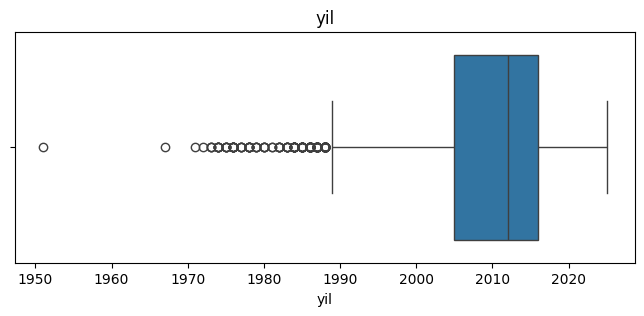

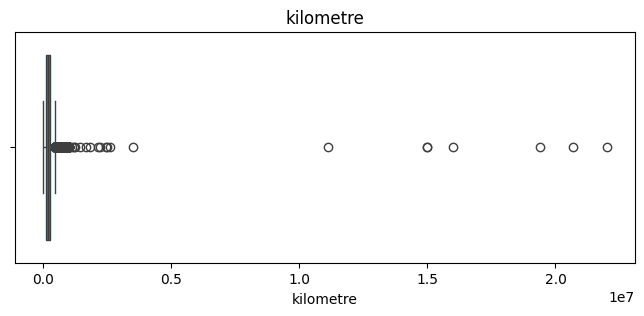

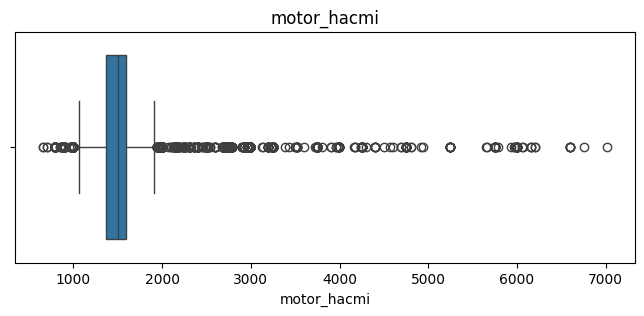

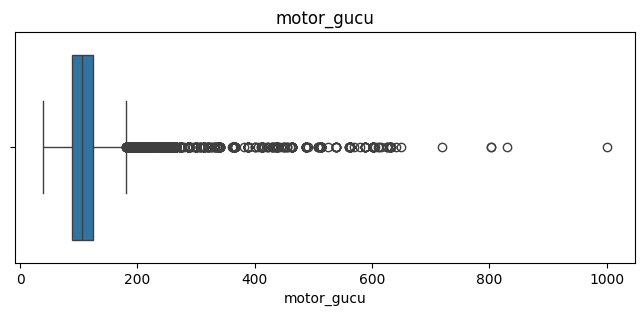

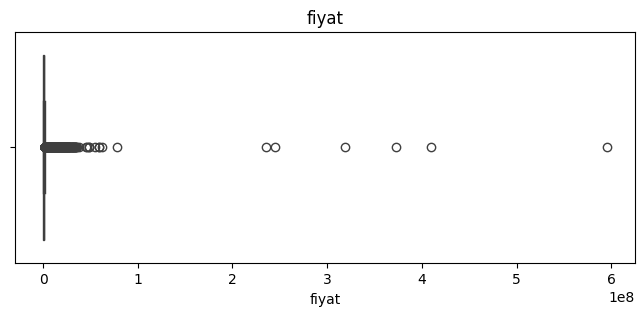

In [15]:
for col in data[["yil", "kilometre", "motor_hacmi", "motor_gucu", "fiyat"]]:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [16]:
print((data["yil"] < 1990).sum())

315


In [17]:
data = data[data["yil"] >= 1990]

In [18]:
print((data["kilometre"] > 1000000).sum())
data = data[data["kilometre"] <= 1000000]

18


In [19]:
data = data[data["fiyat"] <= 10000000]

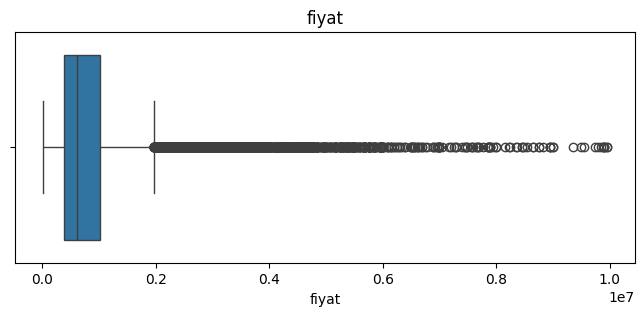

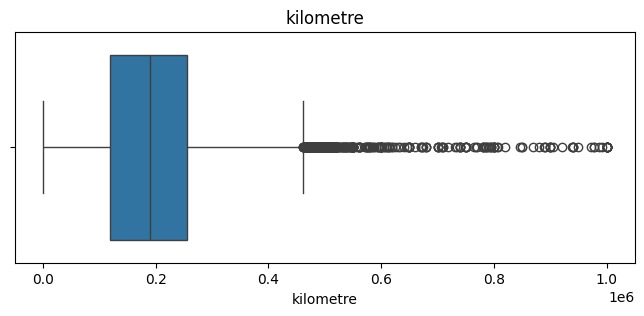

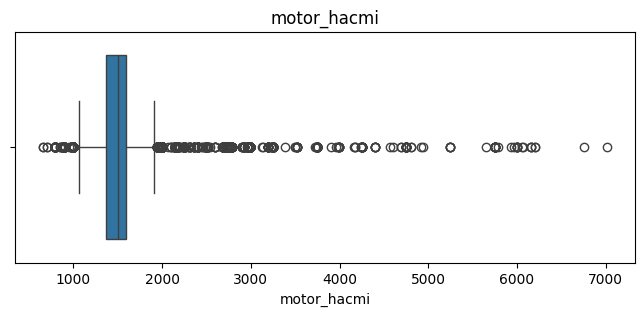

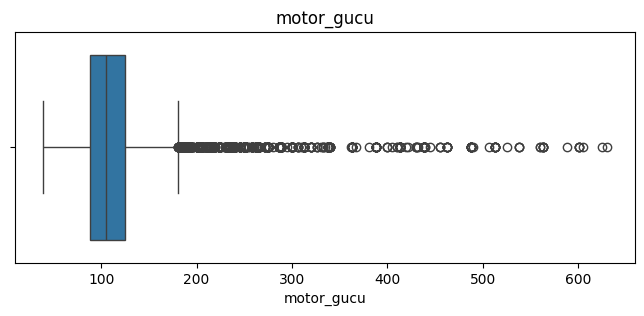

In [20]:
for col in data[["fiyat", "kilometre", "motor_hacmi", "motor_gucu"]]:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

Encoding

In [21]:
data["kimden"].value_counts()

kimden
Galeriden          24189
Sahibinden         23434
Yetkili Bayiden      412
Rent a Car             4
Name: count, dtype: int64

In [22]:
data["vites_tipi"].value_counts()

vites_tipi
Düz              25872
Otomatik         18597
Yarı Otomatik     3570
Name: count, dtype: int64

In [23]:
data["yakit_tipi"].value_counts()

yakit_tipi
Benzin          26289
LPG & Benzin    11598
Dizel            9893
Hibrit            245
Elektrik           14
Name: count, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split

X = data.drop("fiyat", axis=1)
y = data["fiyat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
high_cardinality_cols = ["marka", "seri", "model", "renk"]

for col in high_cardinality_cols:
    
    target_map = y_train.groupby(X_train[col]).mean()
    
    X_train[col] = X_train[col].map(target_map)
    
    X_test[col] = X_test[col].map(target_map)
    
    # Test'te yeni kategori çıkarsa
    X_test[col] = X_test[col].fillna(y_train.mean())

In [26]:
from sklearn.preprocessing import LabelEncoder

low_cardinality_cols = [
    "vites_tipi",
    "yakit_tipi",
    "kasa_tipi",
    "kimden"
]


for col in low_cardinality_cols:
    
    encoder = LabelEncoder()
    
    X_train[col] = encoder.fit_transform(X_train[col])
    
    X_test[col] = encoder.transform(X_test[col])

In [27]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 38431 entries, 4590 to 16807
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   marka                   38431 non-null  float64
 1   seri                    38431 non-null  float64
 2   model                   38431 non-null  float64
 3   yil                     38431 non-null  float64
 4   kilometre               38431 non-null  float64
 5   vites_tipi              38431 non-null  int64  
 6   yakit_tipi              38431 non-null  int64  
 7   kasa_tipi               38431 non-null  int64  
 8   renk                    38431 non-null  float64
 9   motor_hacmi             38431 non-null  float64
 10  motor_gucu              38431 non-null  float64
 11  degisen_sayisi          38431 non-null  float64
 12  boyali_sayisi           38431 non-null  float64
 13  kimden                  38431 non-null  int64  
 14  degisen_sayisi_missing  38431 non-null  int64  
 15

In [28]:
X_train.head()

,marka,seri,model,yil,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,kimden,degisen_sayisi_missing,boyali_sayisi_missing
4590,425875.178832,443831.852941,4.577427e+05,2005.0,250000.0,0,0,9,841804.777722,1500.0,88.0,0.0,11.0,0,0,0
41066,546222.971503,394623.196429,3.745528e+05,2011.0,216000.0,0,1,4,841318.078834,1398.0,71.0,1.0,2.0,2,0,0
32758,920425.216780,995495.892697,6.970000e+05,2012.0,245000.0,0,0,4,934573.041873,1595.0,102.0,0.0,5.0,0,0,0
14850,890618.198133,923793.901525,8.417022e+05,2009.0,253000.0,1,0,9,841318.078834,1595.0,125.0,3.0,4.0,0,0,0
43626,637946.232701,764374.883459,1.729000e+06,2023.0,33000.0,2,3,10,841318.078834,999.0,125.0,0.0,0.0,2,0,0


In [29]:
# X_train.to_csv("X_train.csv", index=False)
# X_test.to_csv("X_test.csv", index=False)
# y_train.to_csv("y_train.csv", index=False)
# y_test.to_csv("y_test.csv", index=False)

MODEL

In [30]:
from sklearn.ensemble import RandomForestRegressor

print("-> Model eğitimi başlatılıyor (Bu işlem 10-15 saniye sürebilir)...")

# Bilgisayarının tüm işlemci çekirdeklerini (n_jobs=-1) devreye sokarak eğitiyoruz
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("-> Eğitim tamamlandı! Skorlar hesaplanıyor...\n")

# Modelin kalitesini ölçüyoruz
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print(f"Gerçekçi/Güvenilir Train R² Skoru: {train_score:.4f}")
print(f"Gerçekçi/Güvenilir Test R² Skoru : {test_score:.4f}")

-> Model eğitimi başlatılıyor (Bu işlem 10-15 saniye sürebilir)...
-> Eğitim tamamlandı! Skorlar hesaplanıyor...

Gerçekçi/Güvenilir Train R² Skoru: 0.9947
Gerçekçi/Güvenilir Test R² Skoru : 0.8831


In [31]:
import joblib
import os

# Eğer models klasörü yoksa kod hata vermesin diye otomatik oluşturuyoruz
if not os.path.exists("models"):
    os.makedirs("models")
    print("-> 'models' klasörü sıfırdan oluşturuldu.")

# Şampiyon modeli bu klasörün içine kaydediyoruz
joblib.dump(rf_model, "models/random_forest_model.pkl")
print("-> Şampiyon model 'models/random_forest_model.pkl' olarak diske başarıyla kilitlendi! 🏆")

-> Şampiyon model 'models/random_forest_model.pkl' olarak diske başarıyla kilitlendi! 🏆
